<!-- Contenedor -->
<div style="max-width:1100px; margin:0 auto;">

  <!-- Dos columnas: izquierda (imágenes), derecha (texto) -->
  <div style="display:flex; align-items:flex-start; gap:1.25rem; margin:1rem 0; flex-wrap:wrap;">
    <!-- Columna izquierda: dos imágenes, mismo ancho, pegadas -->
    <div style="width:20%; min-width:240px; line-height:0;">
      <!-- Imagen 1 -->
      <img
        src="https://cdn.prod.website-files.com/617960145ff34f911afe7243/66f59b40faae94506a4cc751_66f59b0f18152ddb1f3228ab_Automated%2520Trading.jpeg"
        alt="Imagen 1"
        style="width:100%; display:block; margin:0; border:0;" />
      <!-- Imagen 2 con fondo blanco (sin separación) -->
      <div style="background:#fff; margin:0;">
        <img
          src="https://www.ehu.eus/documents/51299803/52066233/Logo-UPV-EHU.png/ce57c7e3-c62b-3b9f-d1a6-395d384f6c2b?t=1710766509885"
          alt="Imagen 2"
          style="width:100%; display:block; margin:0; border:0;" />
      </div>
    </div> 
    <!-- Columna derecha: texto alineado en el mismo margen -->
    <div style="flex:1; min-width:300px; text-align:left;">
      <div style="margin:0; font-size:1.45rem; font-weight:700; line-height:1.15;">
        TRABAJO FINAL DE MÁSTER
      </div>
      <div style="margin:0.65rem 0 0 0; font-size:1.30rem; font-weight:600; line-height:1.2; opacity:0.95;">
        Máster en Finanzas y Dirección Financiera
      </div>
      <div style="margin:1.8rem 0 0 0; font-size:1.10rem; font-weight:600; line-height:1.35;">
        Bots de trading inteligentes: estrategias adaptativas impulsadas por <em>machine learning</em> para la optimización de carteras en renta variable, divisas y criptoactivos
      </div>
      <div style="margin-top:1.8rem; font-size:1rem;">
        <p style="margin:0.2rem 0;"><strong>Autor:</strong> Karen Fajardo</p>
        <p style="margin:0.2rem 0;"><strong>Tutor:</strong> PhD. Vicente Ruiz</p>
      </div>
    </div>

  </div>

  <hr style="margin:1.25rem 0;" />
</div>



### Tabla de contenidos
1. [Entorno y dependencias](#1-entorno-y-dependencias)  
2. [Perfil del inversor & IPS](#2-perfil-del-inversor--ips)  
3. [Universo de activos & datos](#3-universo-de-activos--datos)  
4. [Features & Scoring ML](#4-features--scoring-ml)  
5. [Construcción de cartera (medio plazo)](#5-construcción-de-cartera-medio-plazo)  
6. [Validación walk-forward & métricas](#6-validación-walk-forward--métricas)  
7. [Paper trading multi-activo](#7-paper-trading-multi-activo)  
8. [Selección para intradía](#8-selección-para-intradia)  
9. [Resultados, conclusiones y limitaciones](#9-resultados-conclusiones-y-limitaciones)  
10. [Reproducibilidad](#10-reproducibilidad)  


---

### 1. [Entorno y dependencias](#1-entorno-y-dependencias)
Para garantizar la **reproducibilidad** y un flujo de trabajo ordenado, se configuró un entorno virtual en **Python 3.11** con todas las librerías necesarias fijadas en un `requirements.txt`.

- **Entorno virtual (`.venv`)**: aísla las dependencias del proyecto y evita conflictos con otras instalaciones de Python.  
- **Archivo `.env`**: centraliza variables sensibles y de configuración (ej. semillas aleatorias, rutas de datos, claves API).  
- **Semillas globales**: aseguran resultados consistentes en pruebas y entrenamientos de modelos.  
- **Rutas (`settings.py`)**: se definen directorios estándar para `data/`, `models/`, `logs/` y `reports/`, evitando rutas “hardcodeadas”.  
- **Bootstrap**: función que inicializa el proyecto cargando el `.env`, aplicando zona horaria, fijando semillas y creando carpetas.  

Esto permite que cualquier usuario pueda **replicar el entorno** simplemente creando el entorno virtual e instalando dependencias desde `requirements.txt`.
Ademas, se implementó un flujo de trabajo basado en **Git** para gestionar cambios y mantener el historial del proyecto de forma estructurada y con un esquema que permite que cualquier colaborador pueda clonar el proyecto, instalar las dependencias y reproducir el entorno de forma consistente.

In [1]:
# Añadir la RAÍZ del proyecto al sys.path para que 'settings' sea importable
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "settings.py").exists() and (p / "config").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (settings.py + config/)")

PROJECT_ROOT = find_project_root(Path.cwd())

# 1) Raíz del repo (para importar 'settings')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 2) src/ (para importar 'tfm')
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)


PROJECT_ROOT: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading
SRC_DIR: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\src


In [2]:
import numpy as np
from tfm.bootstrap import bootstrap

seed_used = bootstrap()  
print(f"Entorno inicializado. Seed efectiva: {seed_used}")

# Comprobamos que settings se ve correctamente
import importlib, os
settings = importlib.import_module("settings")
print("TZ:", os.environ.get("TZ"))
print("DATA_DIR:", getattr(settings, "DATA_DIR", None))
print("MODELS_DIR:", getattr(settings, "MODELS_DIR", None))
print("LOGS_DIR:", getattr(settings, "LOGS_DIR", None))



Entorno inicializado. Seed efectiva: 42
TZ: Europe/Madrid
DATA_DIR: C:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\data
MODELS_DIR: C:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\models
LOGS_DIR: C:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\logs


### 2. [Perfil del inversor & IPS](#2-perfil-del-inversor--ips) 

In [3]:
import yaml, math
from pathlib import Path
import pandas as pd



def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "settings.py").exists() and (p / "config").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (settings.py + config/).")

try:
    PROJECT_ROOT  # ya definido
except NameError:
    PROJECT_ROOT = find_project_root(Path.cwd())

IPS_PATH = PROJECT_ROOT / "config" / "ips.yaml"
print("IPS_PATH:", IPS_PATH)

required = ["investor_profile","objectives","risk_metrics","restrictions","universes","rebalancing"]
raw = yaml.safe_load(IPS_PATH.read_text(encoding="utf-8"))
missing = [k for k in required if k not in raw]
assert not missing, f"Faltan claves en ips.yaml: {missing}"

r = raw["restrictions"]
assert 0 <= r["min_cash"] <= r["max_cash"] <= 1.0, "Rango de caja inválido."
vol = raw["risk_metrics"]
assert vol["target_volatility"] < vol["max_volatility"], "target_volatility debe ser < max_volatility."

# Resúmenes auditables
perfil = pd.Series(raw["investor_profile"], name="Perfil del inversor").to_frame()
objet  = pd.Series(raw["objectives"],       name="Objetivos").to_frame()
riesgo = pd.Series(raw["risk_metrics"],     name="Métricas de riesgo").to_frame()
techos = pd.Series(raw["restrictions"].get("max_asset_class_weight", {}), name="Techos por clase").to_frame()

display(perfil, objet, riesgo, techos)
raw


IPS_PATH: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\config\ips.yaml


,Perfil del inversor
type,dynamic
risk_tolerance,high
horizon,medium_term
currency,EUR


,Objetivos
target_return,0.12
sharpe_min,1.00


,Métricas de riesgo
target_volatility,0.12
max_volatility,0.18
max_drawdown,0.20


,Techos por clase
equities,0.60
forex,0.25
crypto,0.05


{'investor_profile': {'type': 'dynamic',
  'risk_tolerance': 'high',
  'horizon': 'medium_term',
  'currency': 'EUR'},
 'objectives': {'target_return': 0.12, 'sharpe_min': 1.0},
 'risk_metrics': {'target_volatility': 0.12,
  'max_volatility': 0.18,
  'max_drawdown': 0.2},
 'restrictions': {'max_asset_weight': 0.2,
  'leverage': False,
  'min_cash': 0.05,
  'max_cash': 0.1,
  'cap_mode': 'budgeted',
  'max_asset_class_weight': {'equities': 0.6, 'forex': 0.25, 'crypto': 0.05},
  'max_position_value_eur': 50000},
 'universes': {'equities': True, 'forex': True, 'crypto': True},
 'rebalancing': {'frequency': 'monthly'}}

In [4]:
#Establecemos una formula de validación que asegura que la configuración del perfil del inversor en el YAML sea factible y consistente con las 
#restricciones de presupuesto y liquidez antes de que la optimización de cartera arranque. Esto se conecta con la literatura de risk budgeting 
#y portfolio constraints: un paso fundamental en la gestión cuantitativa es detectar y corregir configuraciones imposibles o que violan 
#restricciones lógicas, ya que de otro modo la optimización se rompe o produce resultados irreales

#Verificar las restricciones de cash , pesos asignados a los activos y se establecen mensajes de errores. 


def validate_ips_budgeted_with_cash(ips: dict):
    errors = []
    r = ips.get("restrictions", {})
    rm = ips.get("risk_metrics", {})

    # --- Riesgo ---
    tv = rm.get("target_volatility")
    mv = rm.get("max_volatility")
    if tv is None or mv is None:
        errors.append("Define 'risk_metrics.target_volatility' y 'risk_metrics.max_volatility'.")
    else:
        if tv < 0 or mv < 0:
            errors.append("Volatilidades deben ser no negativas.")
        if tv > mv:
            errors.append(f"target_volatility ({tv:.2%}) no puede superar max_volatility ({mv:.2%}).")

    # --- Cash ---
    min_cash = r.get("min_cash", 0.0)
    max_cash = r.get("max_cash", 0.0)
    if not (0 <= min_cash <= 1 and 0 <= max_cash <= 1):
        errors.append("min_cash y max_cash deben estar entre 0 y 1.")
    if min_cash > max_cash:
        errors.append(f"min_cash ({min_cash:.0%}) no puede ser mayor que max_cash ({max_cash:.0%}).")

    # --- Peso por activo ---
    maw = r.get("max_asset_weight")
    if maw is None or not (0 < maw <= 1):
        errors.append("max_asset_weight debe estar en (0,1].")

    # --- Cuotas por clase (budgeted y máximos) ---
    cap_mode = r.get("cap_mode", "independent")
    macw = r.get("max_asset_class_weight", {})
    if cap_mode != "budgeted":
        errors.append("cap_mode debe ser 'budgeted' para cuotas presupuestadas y máximos.")
    if not macw:
        errors.append("Define 'restrictions.max_asset_class_weight' para 'budgeted'.")
    else:
        # cuotas en [0,1]
        if any((w is None) or (w < 0) or (w > 1) for w in macw.values()):
            errors.append("Cada cuota en 'max_asset_class_weight' debe estar en [0,1].")

        total_quota = sum(macw.values())

        # Factibilidad con bandas de cash:
        # Debe cumplirse: 1 - max_cash <= sum(quota) <= 1 - min_cash
        lower = 1 - max_cash
        upper = 1 - min_cash
        if total_quota + 1e-9 < lower:
            errors.append(
                f"Suma de cuotas ({total_quota:.2%}) < 1 - max_cash ({lower:.2%}). "
                "Aumenta cuotas o reduce max_cash."
            )
        if total_quota - 1e-9 > upper:
            errors.append(
                f"Suma de cuotas ({total_quota:.2%}) > 1 - min_cash ({upper:.2%}). "
                "Reduce cuotas o disminuye min_cash."
            )

    if errors:
        raise ValueError("Errores en IPS:\n- " + "\n- ".join(errors))

    # Avisos útiles (no bloquean)
    total_quota = sum(macw.values())
    if abs(total_quota - (1 - min_cash)) < 1e-6:
        print("[Aviso] Suma de cuotas ≈ 1 - min_cash: la cartera tenderá a mantener el mínimo de cash.")
    if abs(total_quota - (1 - max_cash)) < 1e-6:
        print("[Aviso] Suma de cuotas ≈ 1 - max_cash: la cartera podría forzar el cash máximo con facilidad.")



### 3. [Universo de activos & datos](#3-universo-de-activos--datos)  
Definimos y validamos el universo de activos financieros a considerar en la optimización de cartera. 
Esto incluye la carga de datos históricos, la verificación de la integridad y calidad de los datos, y la categorización de los activos en clases (acciones, bonos, materias primas, etc.). 
Un universo bien definido es crucial para asegurar que la optimización de cartera se base en información precisa y relevante, 
permitiendo una mejor diversificación y alineación con los objetivos del inversor. 

In [5]:
import yfinance as yf 
import datetime as dt
from pathlib import Path
import yaml
import pyarrow as pa
import warnings
import missingno as msno
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [6]:
print("Descargando datos actualizados desde Yahoo Finance (OHLCV)")

years_of_data = 4
# 1. Fechas
START_DATE = (dt.date.today() - dt.timedelta(days=365*years_of_data)).strftime("%Y-%m-%d")
END_DATE = dt.date.today().strftime("%Y-%m-%d")

# 2. Cargar universo de tickers
universe_path = PROJECT_ROOT / "config" / "universe" / "universe_equities.yaml"
universe = yaml.safe_load(universe_path.read_text(encoding="utf-8"))
symbols_yf = [x["symbol_yf"] for x in universe["tickers"]]

print(f"Tickers totales a descargar: {len(symbols_yf)}")

# 3. Descarga completa OHLCV
raw = yf.download(
    tickers=symbols_yf,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    group_by="ticker",
    progress=False
)

# 4. Construir estructura final con todas las columnas por ticker
full_data = {}

for ticker in symbols_yf:
    try:
        df_t = raw[ticker][["Open", "High", "Low", "Close", "Adj Close", "Volume"]]
        full_data[ticker] = df_t
    except:
        print(f"[WARN] {ticker}: no descargado")

# 5. Crear un MultiIndex DataFrame: niveles → Fecha × (Ticker, Campo)
prices_df = pd.concat(full_data, axis=1)

print("Descarga completada. Dimensiones:", prices_df.shape)

prices_df.head()


Descargando datos actualizados desde Yahoo Finance (OHLCV)
Tickers totales a descargar: 98
Descarga completada. Dimensiones: (1045, 588)


BMNR                                        TSLA              \
Price      Open High Low Close Adj Close Volume        Open        High   
Date                                                                      
2021-11-16  NaN  NaN NaN   NaN       NaN    NaN  334.436676  352.399994   
2021-11-17  NaN  NaN NaN   NaN       NaN    NaN  354.503326  373.213318   
2021-11-18  NaN  NaN NaN   NaN       NaN    NaN  368.850006  370.666656   
2021-11-19  NaN  NaN NaN   NaN       NaN    NaN  366.290009  379.573334   
2021-11-22  NaN  NaN NaN   NaN       NaN    NaN  387.443329  400.649994   

                                    ...         TD                        \
Price              Low       Close  ...        Low      Close  Adj Close   
Date                                ...                                    
2021-11-16  334.059998  351.576660  ...  74.180000  74.190002  62.445080   
2021-11-17  351.833344  363.003326  ...  73.080002  73.379997  61.763290   
2021-11-18  358.339996  365.459991  ...  73.070000  73.220001  61.628616   
2021-11-19  364.233337  379.019989  ...  72.309998  72.629997  61.132023   
2021-11-22  377.476654  385.623322  ...  73.199997  73.220001  61.628616   

                               RY                                      \
Price          Volume        Open        High         Low       Close   
Date                                                                    
2021-11-16   862500.0  105.809998  105.940002  105.139999  105.559998   
2021-11-17  1040100.0  105.550003  105.690002  104.519997  104.790001   
2021-11-18   786400.0  104.790001  104.790001  104.099998  104.629997   
2021-11-19  1465400.0  104.010002  104.529999  103.320000  104.339996   
2021-11-22  1550500.0  104.510002  104.639999  103.610001  103.650002   

                                  
Price       Adj Close     Volume  
Date                              
2021-11-16  91.382423  1123300.0  
2021-11-17  90.715836   616900.0  
2021-11-18  90.577339  1166000.0  
2021-11-19  90.326279  1339700.0  
2021-11-22  89.728943  1938000.0  

[5 rows x 588 columns]

In [7]:
#Df inciial para futura validación de los resultados 
print("Guardado de respaldo (snapshot) de precios OHLCV.")

snapshot_dir = PROJECT_ROOT / "data" / "snapshots"
snapshot_dir.mkdir(parents=True, exist_ok=True)

snapshot_name = f"prices_OHLCV_{dt.date.today().strftime('%Y%m%d')}.csv.gz"
snapshot_path = snapshot_dir / snapshot_name

prices_df.to_csv(snapshot_path, compression="gzip")
print("Snapshot creado correctamente en:", snapshot_path)


Guardado de respaldo (snapshot) de precios OHLCV.
Snapshot creado correctamente en: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\data\snapshots\prices_OHLCV_20251115.csv.gz


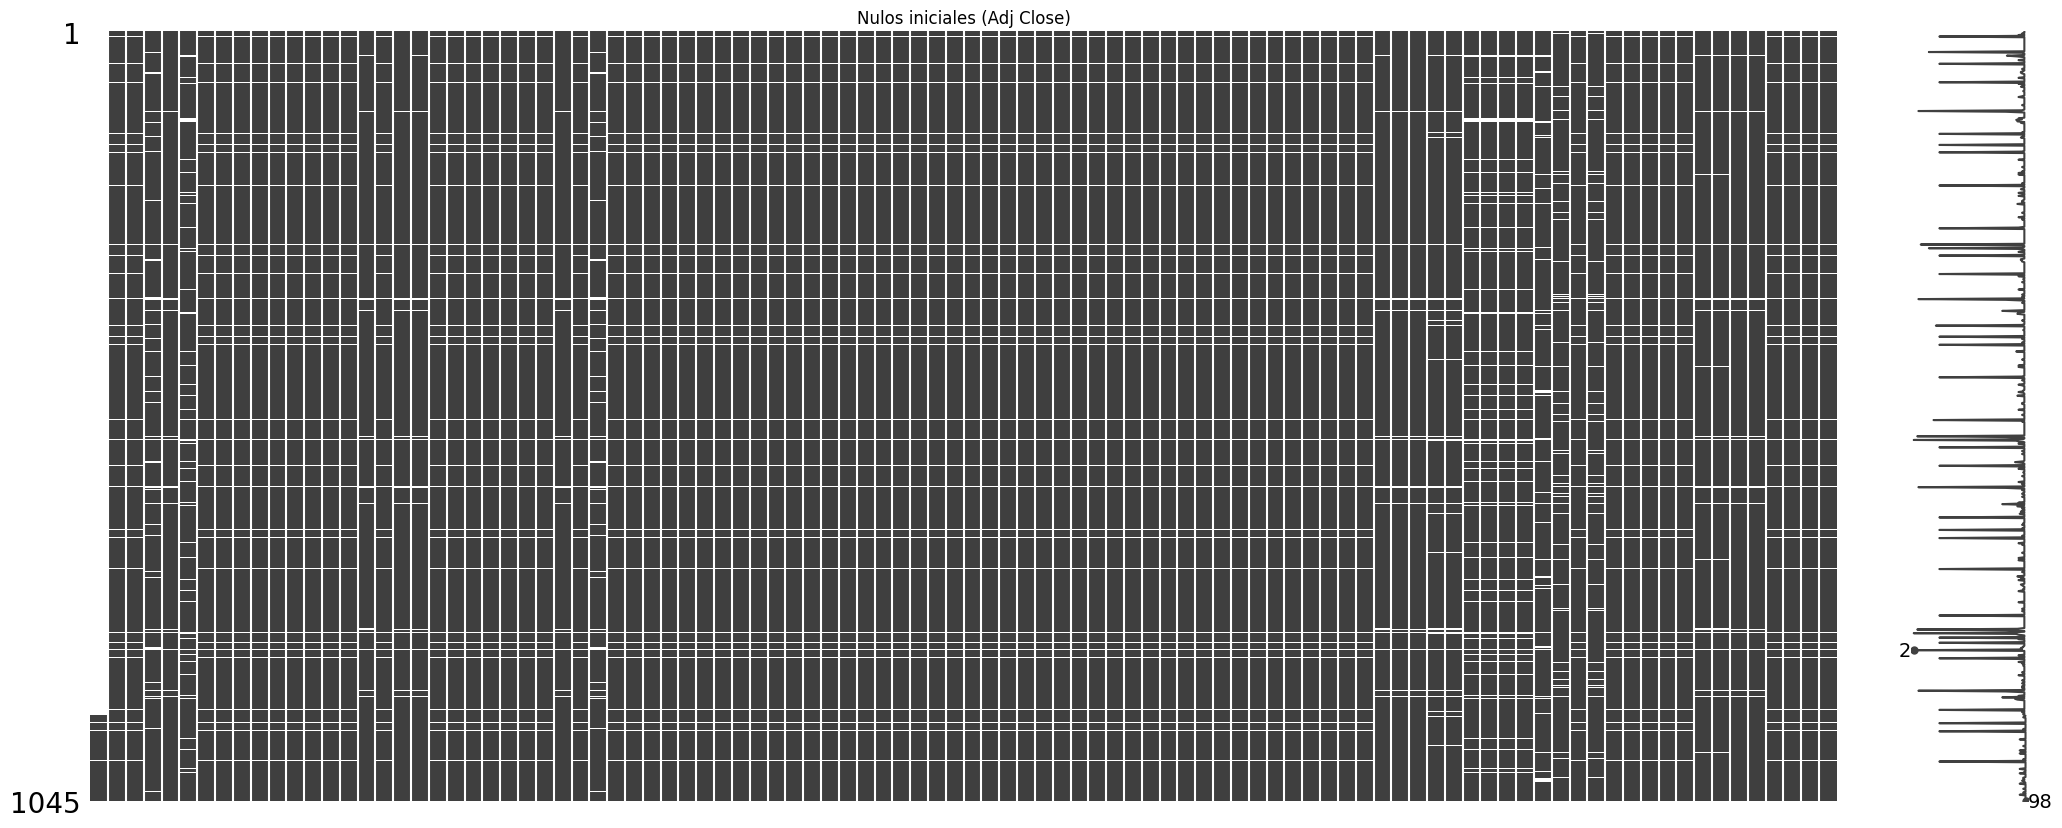

In [8]:
# Extraer OHLCV del MultiIndex
open_df   = prices_df.xs("Open", level=1, axis=1).copy()
high_df   = prices_df.xs("High", level=1, axis=1).copy()
low_df    = prices_df.xs("Low", level=1, axis=1).copy()
close_df  = prices_df.xs("Close", level=1, axis=1).copy()
adj_df    = prices_df.xs("Adj Close", level=1, axis=1).copy()
vol_df    = prices_df.xs("Volume", level=1, axis=1).copy()

# Podemos visualizar solo AdjClose (que resume bien los nulos)
msno.matrix(adj_df)
plt.title("Nulos iniciales (Adj Close)")
plt.show()

In [9]:
# Eliminar activos con >10% nulos en Adj Close 
porcentaje_nulos = adj_df.isna().mean()

tickers_ok = porcentaje_nulos[porcentaje_nulos < 0.10].index
tickers_bad = porcentaje_nulos[porcentaje_nulos >= 0.10].index

print("Activos eliminados (+10% nulos):")
print(list(tickers_bad))

# Filtrar en TODAS las tablas OHLCV
open_df   = open_df[tickers_ok]
high_df   = high_df[tickers_ok]
low_df    = low_df[tickers_ok]
close_df  = close_df[tickers_ok]
adj_df    = adj_df[tickers_ok]
vol_df    = vol_df[tickers_ok]


Activos eliminados (+10% nulos):
['BMNR']


In [10]:
# Unir todas las columnas para detectar días con NaN en cualquier activo o columna
full_matrix = pd.concat(
    [open_df, high_df, low_df, close_df, adj_df, vol_df],
    axis=1
)

# Fechas válidas (sin ningún NaN)
valid_rows = full_matrix.dropna(axis=0, how='any').index

# Aplicar el filtro
open_df   = open_df.loc[valid_rows]
high_df   = high_df.loc[valid_rows]
low_df    = low_df.loc[valid_rows]
close_df  = close_df.loc[valid_rows]
adj_df    = adj_df.loc[valid_rows]
vol_df    = vol_df.loc[valid_rows]

indices_p = adj_df.copy()
print("Después de limpieza total, dimensiones finales:", indices_p.shape)
  

Después de limpieza total, dimensiones finales: (811, 97)


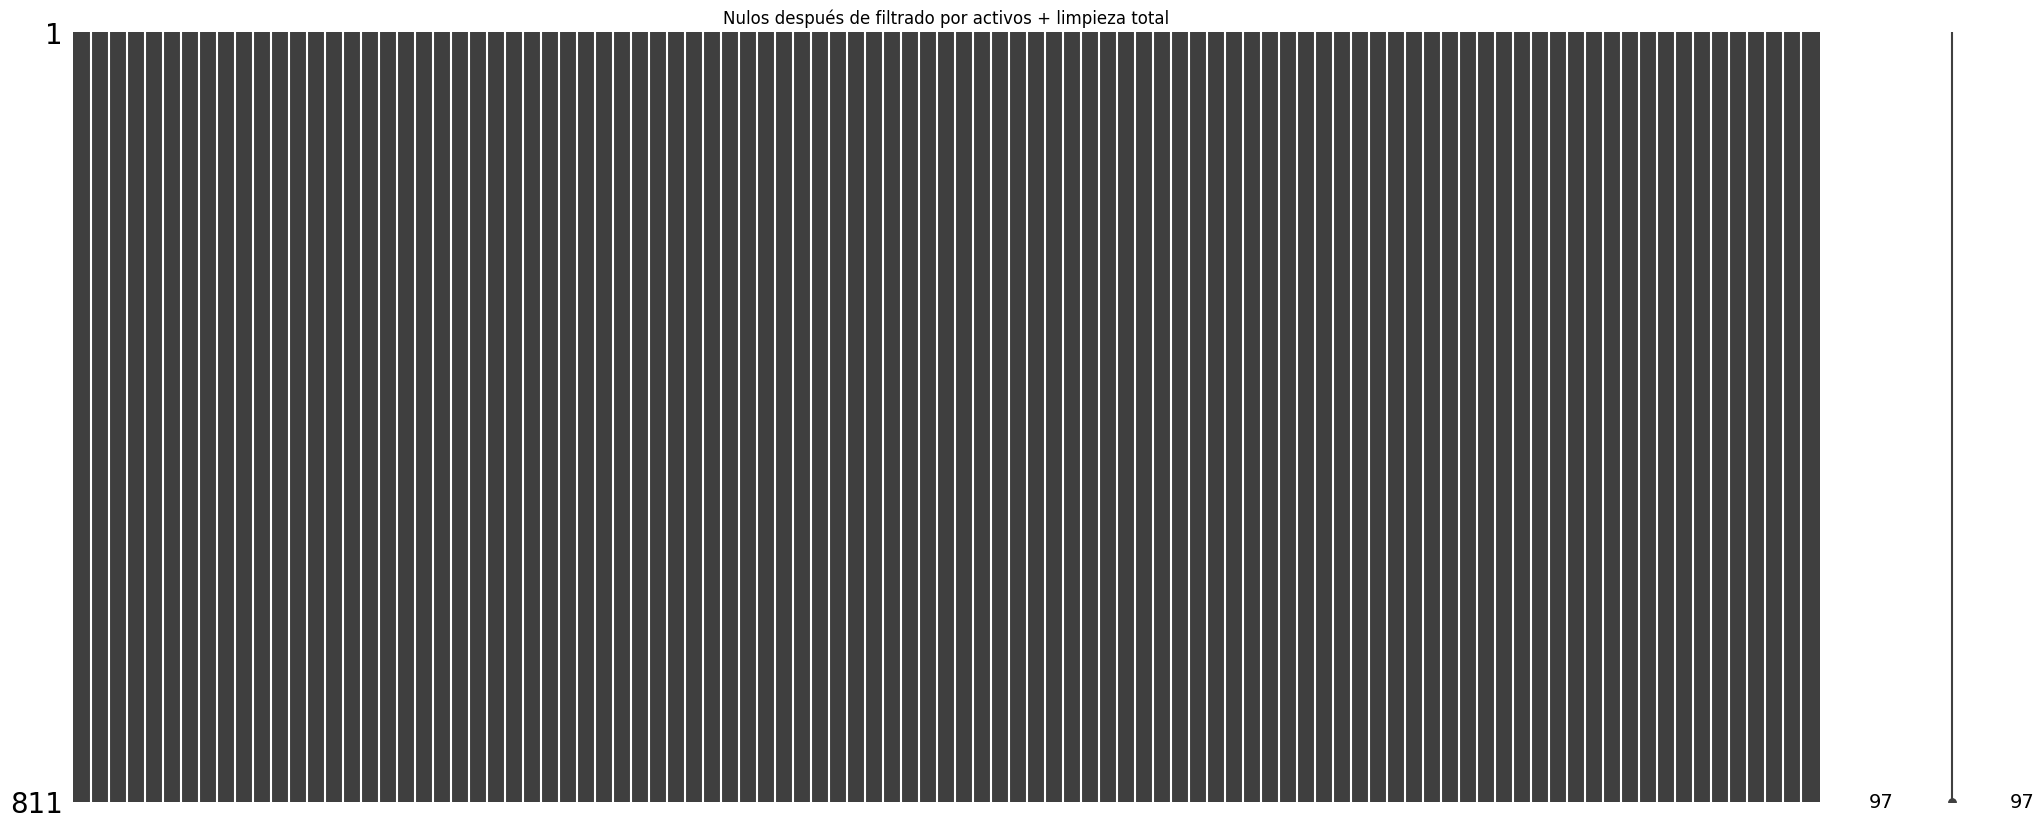

In [11]:
msno.matrix(adj_df)
plt.title("Nulos después de filtrado por activos + limpieza total")
plt.show()


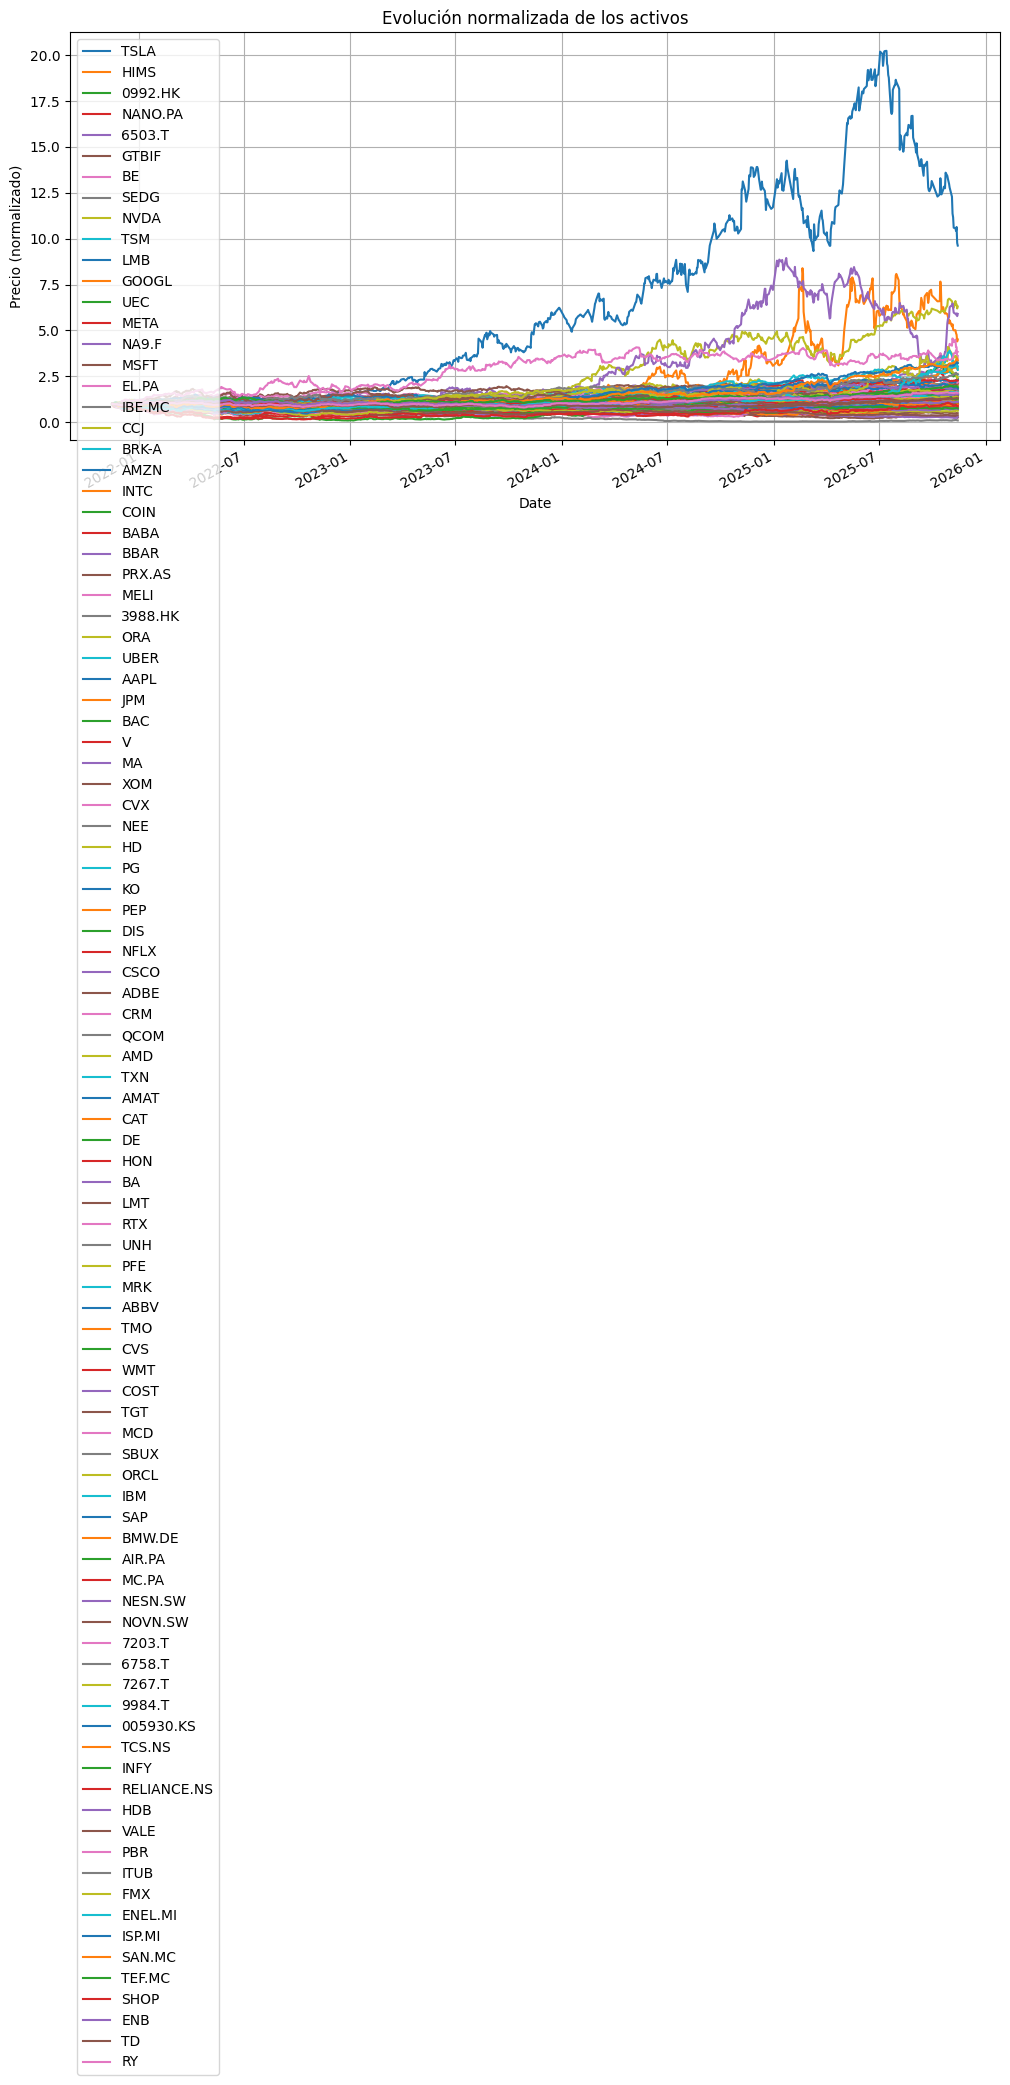

In [12]:
#Grafica de la evolución normalizada de los precios de los activos
indices_p = indices_p.dropna(axis=0, how='any')

activos_precios = indices_p / indices_p.iloc[0, :]

activos_precios.plot(figsize=(12, 6))
plt.title("Evolución normalizada de los activos")
plt.ylabel("Precio (normalizado)")
plt.grid(True)
plt.show()


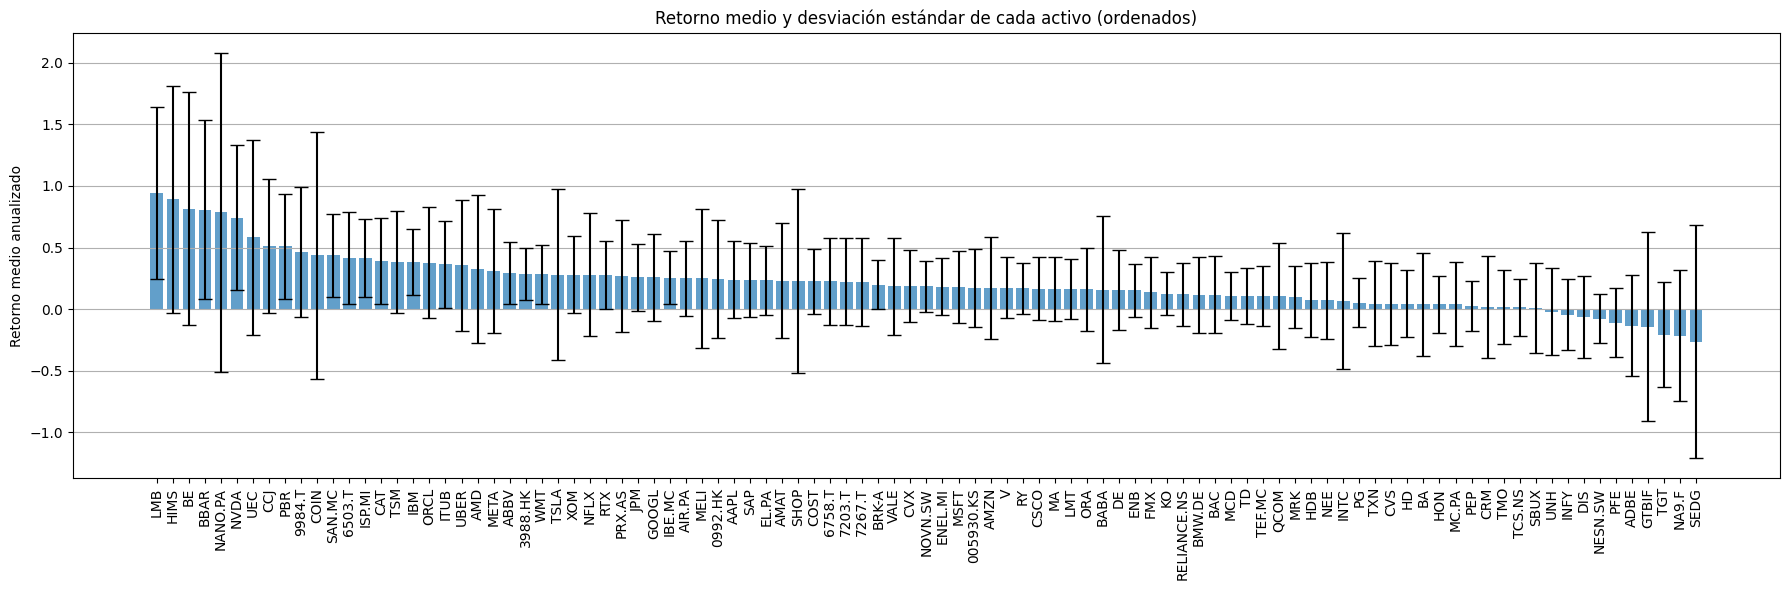

In [13]:
# Cálculo de retornos diarios, media anualizada y desviación estándar anualizada
retornos_activos = indices_p.pct_change().dropna()

# ==== Métricas anualizadas ====
media = retornos_activos.mean() * 252
desviacion = retornos_activos.std() * np.sqrt(252)

# ==== Sharpe simple (sin RF por ahora) ====
sharpe = media / desviacion

# ==== Ordenamiento por retorno ====
orden = media.sort_values(ascending=False).index
media_sorted = media[orden]
desviacion_sorted = desviacion[orden]

#Volumen medio diario
volumen = vol_df.mean()


plt.figure(figsize=(18, 6))
plt.bar(media_sorted.index, media_sorted.values, 
        yerr=desviacion_sorted.values, 
        capsize=5, alpha=0.7)

plt.xticks(rotation=90)
plt.ylabel('Retorno medio anualizado')
plt.title('Retorno medio y desviación estándar de cada activo (ordenados)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [14]:
# Cargar universo y clasificar por región, para visualizar mejor los resultados 
universe_path = PROJECT_ROOT / "config" / "universe" / "universe_equities.yaml"
universe = yaml.safe_load(universe_path.read_text(encoding="utf-8"))
df_universe = pd.DataFrame(universe["tickers"])

# Clasificación por región
def map_region(country):
    country = country.lower()

    if country in ["usa", "united states"]:
        return "usa"
    if country in ["china", "hong kong"]:
        return "china"
    if country in ["spain", "france", "germany", "italy", "netherlands", "switzerland"]:
        return "europe"
    if country in ["japan", "india", "south korea", "taiwan"]:
        return "asia"
    if country in ["brazil", "mexico", "argentina"]:
        return "latam"
    return "other"

df_universe["region"] = df_universe["country"].apply(map_region)

# Agrupar símbolos por región
regiones = (
    df_universe.groupby("region")["symbol_yf"]
    .apply(list)
    .to_dict()
)

color_map = {
    "usa": "#1f77b4",      # azul
    "china": "#ff7f0e",    # naranja
    "europe": "#2ca02c",   # verde
    "asia": "#9467bd",     # púrpura
    "latam": "#d62728",    # rojo
    "other": "#7f7f7f"     # gris
}


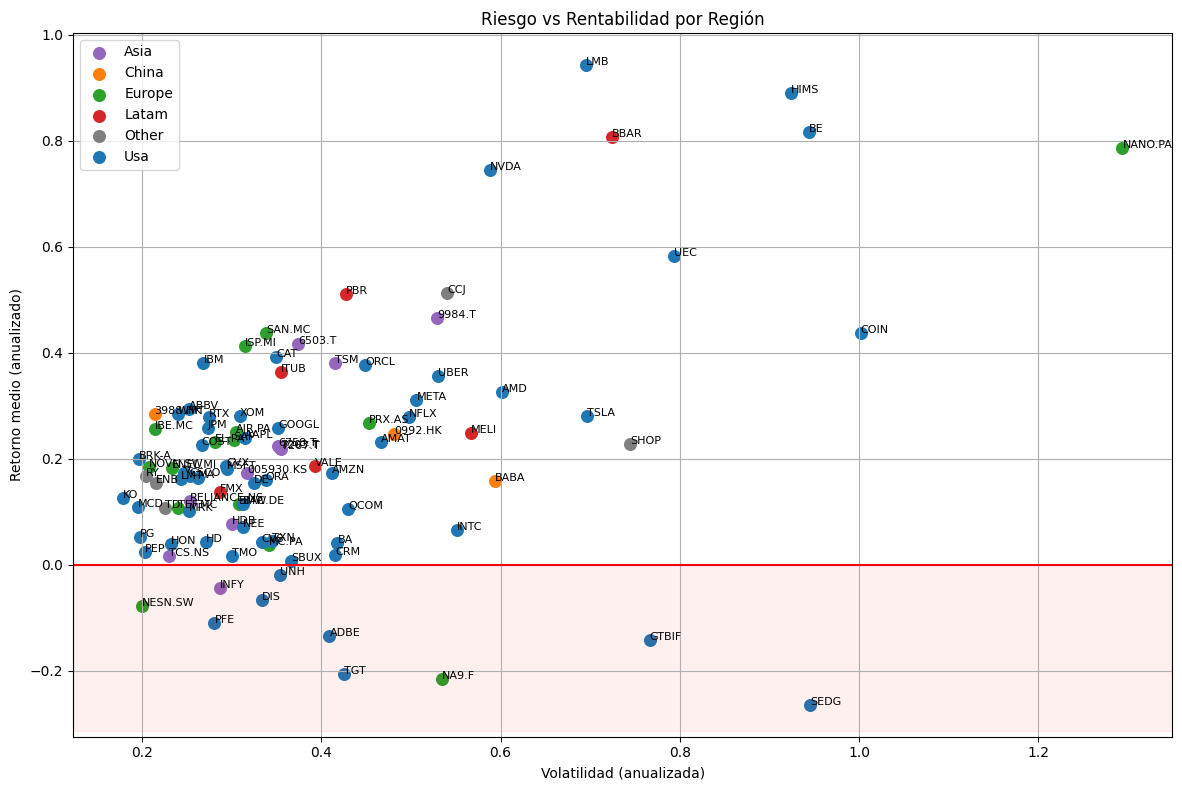

In [15]:
# Gráfico Riesgo vs Rentabilidad por región
plt.figure(figsize=(12, 8))

for region, tickers in regiones.items():

    tickers_validos = [t for t in tickers if t in media.index]

    plt.scatter(
        desviacion[tickers_validos],
        media[tickers_validos],
        color=color_map[region],
        label=region.capitalize(),
        s=70
    )

# Línea roja en y=0
plt.axhline(0, color='red', linewidth=1.5)

# Sombreado rojo bajo cero
plt.axhspan(min(media)-0.05, 0, color='red', alpha=0.06)

# Etiquetas
for t in media.index:
    plt.text(desviacion[t], media[t], t, fontsize=8)

plt.xlabel("Volatilidad (anualizada)")
plt.ylabel("Retorno medio (anualizado)")
plt.title("Riesgo vs Rentabilidad por Región")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Preparación de features para clustering “cartera eficiente”
features_port = pd.DataFrame({
    "mean": media,
    "vol": desviacion,
    "volume": volumen,
    "sharpe": sharpe
}).dropna()

scaler_port = StandardScaler()
X_port = scaler_port.fit_transform(features_port)

kmeans_port = KMeans(n_clusters=4, random_state=42)
features_port["cluster_port"] = kmeans_port.fit_predict(X_port)

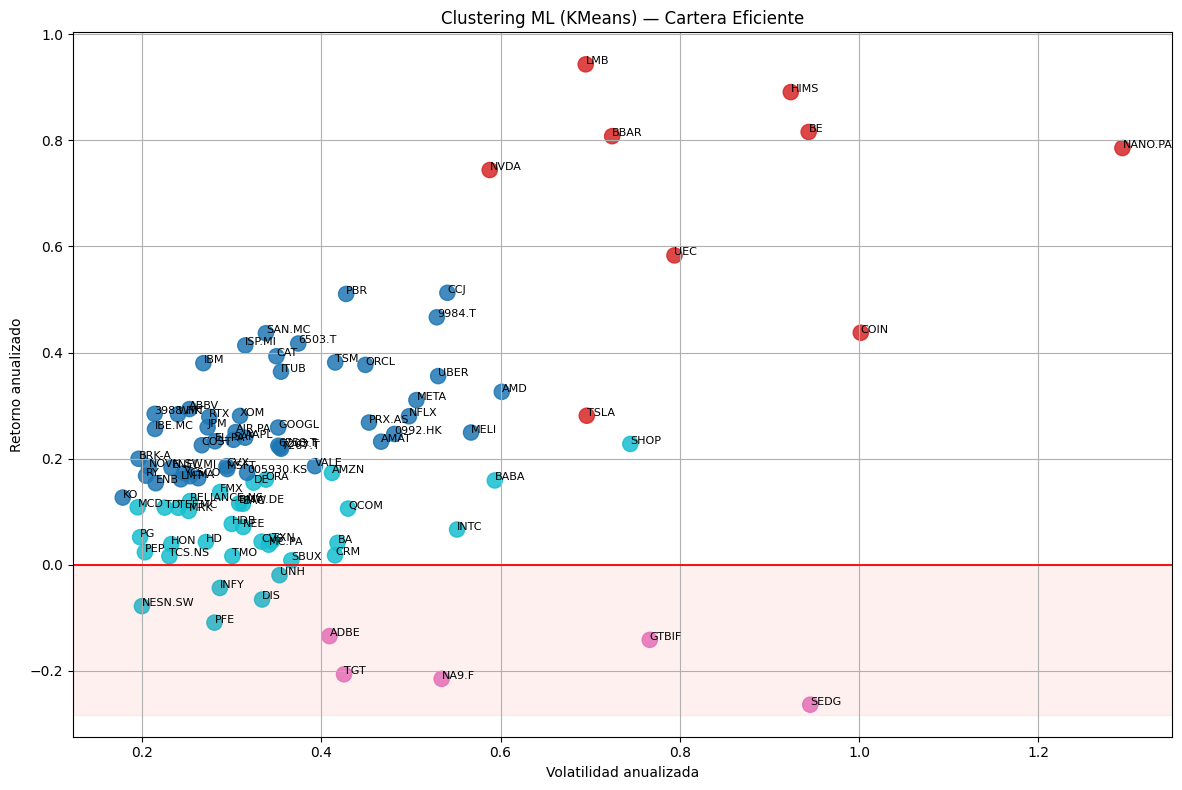

In [17]:
#Grafico del clustering de cartera eficiente 
plt.figure(figsize=(12, 8))

# scatter coloreado por CLUSTER
plt.scatter(
    features_port["vol"],
    features_port["mean"],
    c=features_port["cluster_port"],
    cmap="tab10",
    s=120,
    alpha=0.85
)

# Etiquetas con nombre del ticker
for ticker in features_port.index:
    plt.text(
        features_port.loc[ticker, "vol"],
        features_port.loc[ticker, "mean"],
        ticker,
        fontsize=8
    )

# Línea horizontal en y = 0
plt.axhline(0, color='red', linewidth=1.3)

# Sombreado rojo (rentabilidad negativa)
plt.axhspan(features_port["mean"].min() - 0.02, 0,
            color='red', alpha=0.06)

plt.xlabel("Volatilidad anualizada")
plt.ylabel("Retorno anualizado")
plt.title("Clustering ML (KMeans) — Cartera Eficiente")
plt.grid(True)
plt.tight_layout()
plt.show()



In [18]:
features_summary = features_port.groupby("cluster_port").agg({
    "mean": ["mean", "median"],
    "vol": ["mean", "median"],
    "sharpe": ["mean", "median"],
    "volume": ["mean", "median"]
})


#Lista de los activos en el cluster 2
activos_cluster_2 = features_port[features_port["cluster_port"] == 3].index.tolist()
print("Activos en el cluster 2 (Cartera Eficiente):")
print(activos_cluster_2)

Activos en el cluster 2 (Cartera Eficiente):
['AMZN', 'INTC', 'BABA', 'ORA', 'BAC', 'NEE', 'HD', 'PG', 'PEP', 'DIS', 'CRM', 'QCOM', 'TXN', 'DE', 'HON', 'BA', 'UNH', 'PFE', 'MRK', 'TMO', 'CVS', 'MCD', 'SBUX', 'BMW.DE', 'MC.PA', 'NESN.SW', 'TCS.NS', 'INFY', 'RELIANCE.NS', 'HDB', 'FMX', 'TEF.MC', 'SHOP', 'TD']


Arquitectura que implementaremos desde ese punto:
Fase 1 — Preparación única train/test

(Sin duplicaciones; rolling windows correctos; panel limpio)

Fase 2 — ML supervisado a todo el universo

RandomForestRegressor y GradientBoostingRegressor
(predicción individual por activo)

Fase 3 — Ranking de activos

Función ponderada: predicción + sharpe + momentum

Fase 4 — Selección diversificada

(máx 2 activos por sector, región, etc.)

Fase 5 — HRP

Optimización final con el universo seleccionado

Fase 6 — Backtest mensual

comparación con equal-weight, benchmark, drawdown y sharpe



In [19]:
#PREPARACION DE TRAIN Y TEST SETS PARA ML MODELS
horizon = 21    # horizonte de predicción (días hacia adelante, ~1 mes)
test_days = 21  # número de fechas para el conjunto de test

# 1.1. Panel (Date, Asset) con retornos diarios de TODO el universo
panel = retornos_activos.stack().to_frame("ret")
panel.index.names = ["Date", "Asset"]

g = panel.groupby("Asset")["ret"]

# 1.2. Features rolling (momentum y volatilidad)
panel["ret_1m"] = g.rolling(horizon).sum().reset_index(level=0, drop=True)
panel["ret_3m"] = g.rolling(3 * horizon).sum().reset_index(level=0, drop=True)
panel["ret_6m"] = g.rolling(6 * horizon).sum().reset_index(level=0, drop=True)

panel["vol_1m"] = g.rolling(horizon).std().reset_index(level=0, drop=True)
panel["vol_3m"] = g.rolling(3 * horizon).std().reset_index(level=0, drop=True)
panel["vol_6m"] = g.rolling(6 * horizon).std().reset_index(level=0, drop=True)


#Feature	Significado
#ret_1m	Retorno acumulado 21 días (momentum corto)
#ret_3m	Retorno acumulado 63 días (momentum medio)
#ret_6m	Retorno acumulado 126 días (momentum largo)
#vol_1m	Volatilidad 21 días
#vol_3m	Volatilidad 63 días
#vol_6m	Volatilidad 126 día


# 1.3. Target: retorno acumulado de los próximos 21 días
panel["target_21d"] = (
    g.rolling(horizon).sum()
     .shift(-horizon)
     .reset_index(level=0, drop=True)
)

# 1.4. Eliminar filas con nulos (por ventanas y target)
panel = panel.dropna()

# 1.5. Split único train/test:
#      - tomamos las ÚLTIMAS 25 fechas del panel como test
all_dates = panel.index.get_level_values("Date").unique()
test_dates = all_dates[-test_days:]

date_index = panel.index.get_level_values("Date")
train_mask = ~date_index.isin(test_dates)
test_mask  = date_index.isin(test_dates)

train = panel.loc[train_mask]
test  = panel.loc[test_mask]
test = test.copy()  # evitar SettingWithCopyWarning

print("Fechas de test:", test_dates.min(), "→", test_dates.max())
print("Observaciones train:", len(train))
print("Observaciones test:", len(test))

# 1.6. Matrices X e y
features_ml = ["ret_1m", "ret_3m", "ret_6m", "vol_1m", "vol_3m", "vol_6m"]

X_train = train[features_ml]
y_train = train["target_21d"]

X_test = test[features_ml]
y_test = test["target_21d"]

Fechas de test: 2025-08-29 00:00:00 → 2025-11-14 00:00:00
Observaciones train: 62468
Observaciones test: 2036


In [20]:
#MODELOS DE ML PARA PREDICCIÓN DE RETORNOS A 21 DÍAS

#=======================================
# PIPELINE DE MODELOS DE ML PARA PREDECIR RETORNOS A 21 DÍAS (ML UNIVERSAL)
# Incluye: RandomForest, GradientBoosting, ExtraTrees, XGBoost*, LightGBM*
#=======================================

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV


# 1. Escalado único del dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# 2. Diccionario de modelos
models_and_params = {

    "RandomForest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 300],
            "max_depth": [4, 6, 8]
        }
    ),

    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [2, 3, 4]
        }
    ),

    "ExtraTrees": (
        ExtraTreesRegressor(random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 300],
            "max_depth": [4, 6, None]
        }
    )
}

# Intentar cargar XGBoost
try:
    from xgboost import XGBRegressor
    models_and_params["XGBoost"] = (
        XGBRegressor(objective="reg:squarederror", random_state=42),
        {
            "n_estimators": [200, 300],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5, 7]
        }
    )
except:
    print("XGBoost no instalado, se omite.")

# Intentar cargar LightGBM
try:
    from lightgbm import LGBMRegressor
    models_and_params["LightGBM"] = (
        LGBMRegressor(objective="regression", random_state=42),
        {
            "n_estimators": [200, 400],
            "learning_rate": [0.05, 0.1]
        }
    )
except:
    print("LightGBM no instalado, se omite.")





In [ ]:
# 3. Evaluación de modelos
tscv = TimeSeriesSplit(n_splits=4)

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0,1]
    da   = np.mean((np.sign(y_true) == np.sign(y_pred)).astype(int))

    print(f"\n=== {name} ===")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.4f}")
    print(f"Correlación pred vs real: {corr:.3f}")
    print(f"Directional Accuracy: {da:.2%}")

    return mae, rmse, r2, corr, da

best_models = []
results_table = []

for name, (model, params) in models_and_params.items():

    print(f"\n##### OPTIMIZANDO: {name} #####")

    gs = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        n_jobs=-1
    )
    gs.fit(X_train_scaled, y_train)

    best_model = gs.best_estimator_
    pred_test  = best_model.predict(X_test_scaled)

    mae, rmse, r2, corr, da = evaluate_model(name, y_test, pred_test)

    best_models.append({
        "name": name,
        "model": best_model,
        "pred": pred_test,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "corr": corr,
        "da": da
    })

    results_table.append({
        "model": name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "corr": corr,
        "da": da,
        "params": gs.best_params_
    })

results_df = pd.DataFrame(results_table)
print("\n===== RESUMEN DE MODELOS =====")
display(results_df)


# 4. Selección del mejor modelo
# criterio: mínimo MAE + máxima Directional Accuracy
results_df["rank_mae"] = results_df["mae"].rank()
results_df["rank_da"]  = (-results_df["da"]).rank()

results_df["score_final"] = results_df["rank_mae"] + results_df["rank_da"]

best_row = results_df.sort_values("score_final").iloc[0]
chosen_model_name = best_row["model"]

print("\n### MODELO SELECCIONADO:", chosen_model_name, "###")

# obtener las predicciones del modelo ganador
for m in best_models:
    if m["name"] == chosen_model_name:
        chosen_pred_test = m["pred"]
        chosen_model      = m["model"]
        break


# 5. Guardar predicciones en test
test.loc[:, "pred"] = chosen_pred_test
print("Predicciones guardadas en test['pred']")

#MAE: Mean Absolute Error, mae mas bajo = modelo mas preciso
#RMSE: Root Mean Squared Error, rmse mas bajo = modelo mas preciso (penaliza errores grandes)
#R2: Coeficiente de determinación, >0 indica buen ajuste, 1 es perfecto, =0 es media, <0 mal ajuste
#Correlación pred vs real: Correlación entre predicciones y valores reales, más cerca de 1 es mejor
#Directional Accuracy: Porcentaje de predicciones con el signo correcto, más alto es mejor


##### OPTIMIZANDO: RandomForest #####

=== RandomForest ===
MAE:  0.103955
RMSE: 0.168189
R2:   -0.0423
Correlación pred vs real: 0.147
Directional Accuracy: 65.03%

##### OPTIMIZANDO: GradientBoosting #####

=== GradientBoosting ===
MAE:  0.104058
RMSE: 0.169016
R2:   -0.0526
Correlación pred vs real: 0.099
Directional Accuracy: 65.57%

##### OPTIMIZANDO: ExtraTrees #####

=== ExtraTrees ===
MAE:  0.102650
RMSE: 0.166654
R2:   -0.0234
Correlación pred vs real: 0.250
Directional Accuracy: 65.62%

##### OPTIMIZANDO: XGBoost #####

=== XGBoost ===
MAE:  0.103080
RMSE: 0.162846
R2:   0.0228
Correlación pred vs real: 0.287
Directional Accuracy: 63.90%

##### OPTIMIZANDO: LightGBM #####
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003564 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 62468, number of used features: 6
[LightGBM] [Info] St

,model,mae,rmse,r2,corr,da,params
0,RandomForest,0.103955,0.168189,-0.042344,0.146934,0.650295,"{'max_depth': 4, 'n_estimators': 200}"
1,GradientBoosting,0.104058,0.169016,-0.052610,0.098626,0.655697,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
2,ExtraTrees,0.102650,0.166654,-0.023405,0.249720,0.656189,"{'max_depth': 4, 'n_estimators': 300}"
3,XGBoost,0.103080,0.162846,0.022833,0.287011,0.638998,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
4,LightGBM,0.105002,0.167797,-0.037487,0.197273,0.640963,"{'learning_rate': 0.05, 'n_estimators': 200}"



### MODELO SELECCIONADO: ExtraTrees ###
Predicciones guardadas en test['pred']


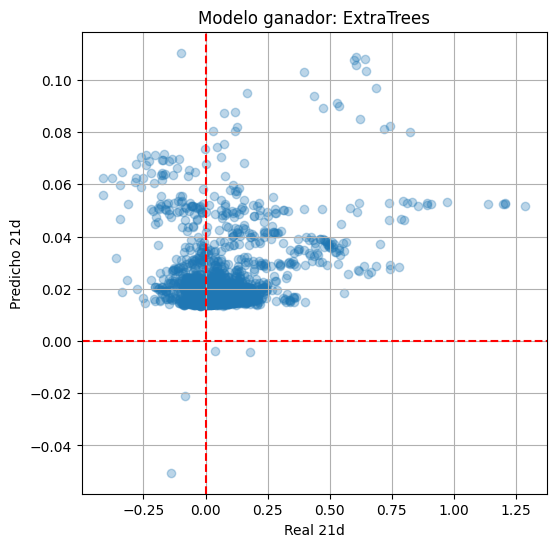

In [22]:
#Grafico de predicción vs real
plt.figure(figsize=(6,6))
plt.scatter(test["target_21d"], test["pred"], alpha=0.3)
plt.xlabel("Real 21d")
plt.ylabel("Predicho 21d")
plt.title(f"Modelo ganador: {chosen_model_name}")
plt.axhline(0, color="red", linestyle="--")
plt.axvline(0, color="red", linestyle="--")
plt.grid(True)
plt.show()

In [ ]:
# 
#Guardar el modelo entrenado y el scaler
import joblib

model_dir = PROJECT_ROOT / "models" / "ml_models"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"{chosen_model_name}_model.pkl"
joblib.dump({
    "model": chosen_model,
    "scaler": scaler
}, model_path)

print("Modelo guardado en:", model_path)

Modelo guardado en: c:\Users\karen\Documents\MASTER_FINANZAS\TFM\TFM-ML-Trading\models\ml_models\ExtraTrees_model.pkl


In [89]:
# Selección de activos por predicción ML (21 días)
# ============================================================
# SELECCIÓN DE ACTIVOS POR ML – HORIZONTE 21 DÍAS
# Criterio temporal:
#   T = hoy - 21 días  → fecha en la que SE CREA la cartera
#   Hoy = última fecha del dataset → fecha en la que SE EVALÚA
#   Creamos cartera en T usando predicciones del modelo ganador.
# ============================================================

# 1. Obtener la lista de fechas del conjunto de test
all_test_dates = test.index.get_level_values("Date").unique()

# 2. Definir T = última fecha útil menos 21 días (fecha donde se crea la cartera)
T = all_test_dates[-21]

# 3. Extraer predicciones ML (target 21 días) de la fecha T para cada activo
pred_T = (
    test.xs(T, level="Date")["pred"]
        .dropna()                   # nos quedamos con activos con predicción válida
)

# 4. Filtrar activos cuya rentabilidad esperada es positiva (> 0)
pred_positive = pred_T[pred_T > 0]

# 5. Ordenar por mayor rentabilidad esperada
pred_sorted = pred_positive.sort_values(ascending=False)

# 6. Limitar a un máximo de 30 activos (criterio de diversificación inicial)
max_n = 25
if pred_sorted.shape[0] > max_n:
    pred_sorted = pred_sorted.head(max_n)

# 7. Lista final de activos seleccionados por ML (creación de cartera en T)
selected_assets_ml = pred_sorted.index.tolist()

# 8. Resumen
print("================================================")
print("SELECCIÓN DE ACTIVOS POR ML (HORIZONTE 21 DÍAS)")
print("Fecha actual:", all_test_dates[-1])
print("Fecha T (creación cartera):", T)
print("Activos con predicción > 0:", pred_positive.shape[0])
print(f"Activos finalmente seleccionados (máx {max_n}): {len(selected_assets_ml)}")
print("Ejemplo:", selected_assets_ml[:10])
print("================================================")


SELECCIÓN DE ACTIVOS POR ML (HORIZONTE 21 DÍAS)
Fecha actual: 2025-11-14 00:00:00
Fecha T (creación cartera): 2025-08-29 00:00:00
Activos con predicción > 0: 97
Activos finalmente seleccionados (máx 25): 25
Ejemplo: ['HIMS', 'COIN', 'NANO.PA', 'SEDG', 'GTBIF', 'BE', 'BBAR', 'UEC', 'LMB', 'TSLA']


In [90]:
# ESTADÍSTICAS HISTÓRICAS PARA ACTIVOS SELECCIONADOS POR ML
# Se calculan con datos hasta T (fecha de creación de la cartera)
# Variables: media anualizada, volatilidad anualizada, Sharpe,
# retorno acumulado 1m/3m/6m, y covarianza para Markowitz/HRP.

# 1. Filtrar retornos solo para los activos seleccionados
returns_sel = retornos_activos[selected_assets_ml]

# 2. Recortar histórico PARA NO USAR DATOS POSTERIORES A T
returns_sel_T = returns_sel.loc[:T]   # histórico válido hasta la fecha de creación

# 3. Medias y volatilidades anualizadas (252 días)
mu_sel = returns_sel_T.mean() * 252
sigma_sel = returns_sel_T.std() * np.sqrt(252)

# 4. Sharpe ratio simple (rf = 0)
sharpe_sel = mu_sel / sigma_sel

# 5. Matriz de covarianzas anualizada (para Markowitz y HRP)
cov_sel = returns_sel_T.cov() * 252

# 6. Momentum histórico hasta T
mom_1m_sel = returns_sel_T.rolling(21).sum().iloc[-1]
mom_3m_sel = returns_sel_T.rolling(63).sum().iloc[-1]
mom_6m_sel = returns_sel_T.rolling(126).sum().iloc[-1]

# 7. Un pequeño DataFrame resumen de estadísticas
stats_sel = pd.DataFrame({
    "mu_annual": mu_sel,
    "sigma_annual": sigma_sel,
    "sharpe": sharpe_sel,
    "mom_1m": mom_1m_sel,
    "mom_3m": mom_3m_sel,
    "mom_6m": mom_6m_sel
}).sort_values("sharpe", ascending=False)

print("ESTADÍSTICAS HISTÓRICAS – ACTIVOS SELECCIONADOS")
print(stats_sel.head())



ESTADÍSTICAS HISTÓRICAS – ACTIVOS SELECCIONADOS
      mu_annual  sigma_annual    sharpe    mom_1m    mom_3m    mom_6m
LMB    1.138353      0.698255  1.630282 -0.128469 -0.020134  0.330362
BBAR   0.722390      0.668894  1.079976 -0.246696 -0.521535 -0.546673
HIMS   0.958466      0.922708  1.038753 -0.281063 -0.166563  0.896870
ORCL   0.373706      0.388382  0.962211 -0.074922  0.377319  0.430276
CCJ    0.495741      0.527126  0.940460 -0.022165  0.428699  0.510818


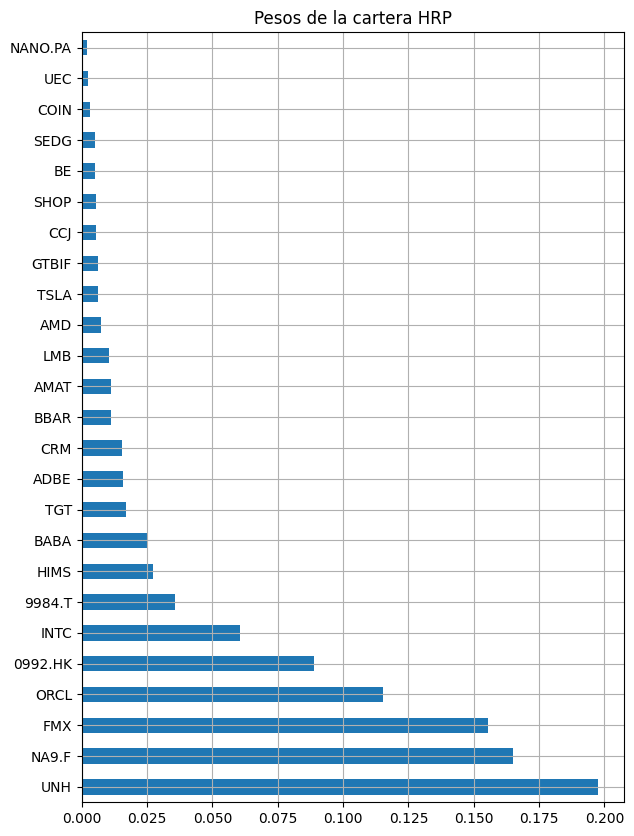

,weight,sector,country
UNH,0.197671,Healthcare,USA
NA9.F,0.165155,Technology,Germany
FMX,0.155426,Consumer,Mexico
ORCL,0.115082,Technology,USA
0992.HK,0.088708,Technology / Hardware,China
INTC,0.060372,Semiconductors,USA
9984.T,0.035657,Technology / Holdings,Japan
HIMS,0.027300,Healthcare,USA
BABA,0.025020,E-Commerce / Technology,China
TGT,0.016867,Retail / Consumer,USA


In [91]:
# Construcción de cartera HRP usando los activos seleccionados
# Hierarchical Risk Parity (HRP)
# Método de construcción de carteras que asigna pesos basándose solo en la estructura del riesgo, 
# evitando los problemas clásicos del método de Markowitz (inestabilidad de la inversa de la matriz de covarianza).
# Reparte el riesgo entre los grupos de forma equilibrada, evitando concentraciones.


# 1. Matriz de correlación y distancias
corr_sel = returns_sel_T[selected_assets_ml].corr()
dist_sel = np.sqrt((1 - corr_sel) / 2)

# 2. Enlace jerárquico para clustering
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

linkage_sel = linkage(squareform(dist_sel), method="ward")

# 3. Función de ordenación quasi-diagonal
def get_quasi_diag(link):
    link = link.astype(int)
    n = link[-1, 3]
    cluster = [int(link[-1, 0]), int(link[-1, 1])]
    ordered = []
    while cluster:
        i = cluster.pop(0)
        if i < n:
            ordered.append(i)
        else:
            i -= n
            cluster = [int(link[i, 0]), int(link[i, 1])] + cluster
    return ordered

# 4. Obtener el orden óptimo de tickers
ordered_idx = get_quasi_diag(linkage_sel)
ordered_tickers = corr_sel.columns[ordered_idx]

# 5. Función HRP para asignar pesos
def get_hrp_weights(cov, ordered_tickers):
    weights = pd.Series(1.0, index=ordered_tickers)
    clusters = [ordered_tickers]

    while clusters:
        cluster = clusters.pop(0)
        if len(cluster) <= 1:
            continue
        split = len(cluster) // 2
        left = cluster[:split]
        right = cluster[split:]

        var_left = np.sum(cov.loc[left, left].values)
        var_right = np.sum(cov.loc[right, right].values)

        alpha = 1 - var_left / (var_left + var_right)

        weights[left] *= alpha
        weights[right] *= (1 - alpha)

        clusters.append(left)
        clusters.append(right)

    return weights / weights.sum()

# 6. Calcular los pesos HRP
weights_hrp = get_hrp_weights(cov_sel, ordered_tickers)
weights_hrp = weights_hrp.sort_values(ascending=False)

# 7. Gráfico de pesos HRP
plt.figure(figsize=(7, 10))
weights_hrp.plot(kind="barh")
plt.title("Pesos de la cartera HRP")
plt.grid(True)
plt.show()

# 8. Tabla final con los activos, pesos, sector y país
df_weights_hrp = pd.DataFrame(weights_hrp, columns=["weight"])
df_weights_hrp = df_weights_hrp.join(df_universe[["sector", "country"]], how="left")
df_weights_hrp



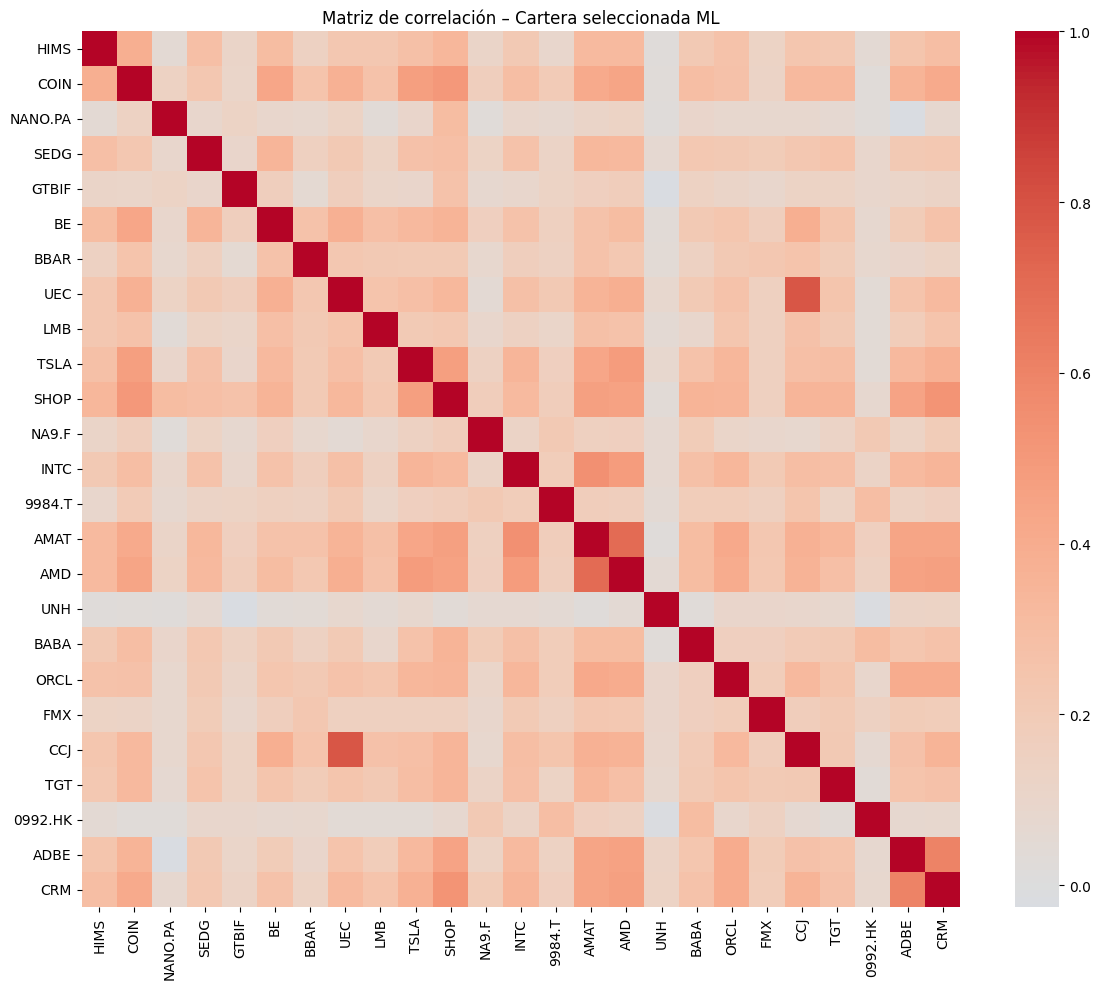

In [92]:
# Heatmap de la matriz de correlación de los activos seleccionados
import seaborn as sns
corr_matrix = returns_sel_T[selected_assets_ml].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, center=0)
plt.title("Matriz de correlación – Cartera seleccionada ML")
plt.tight_layout()
plt.show()


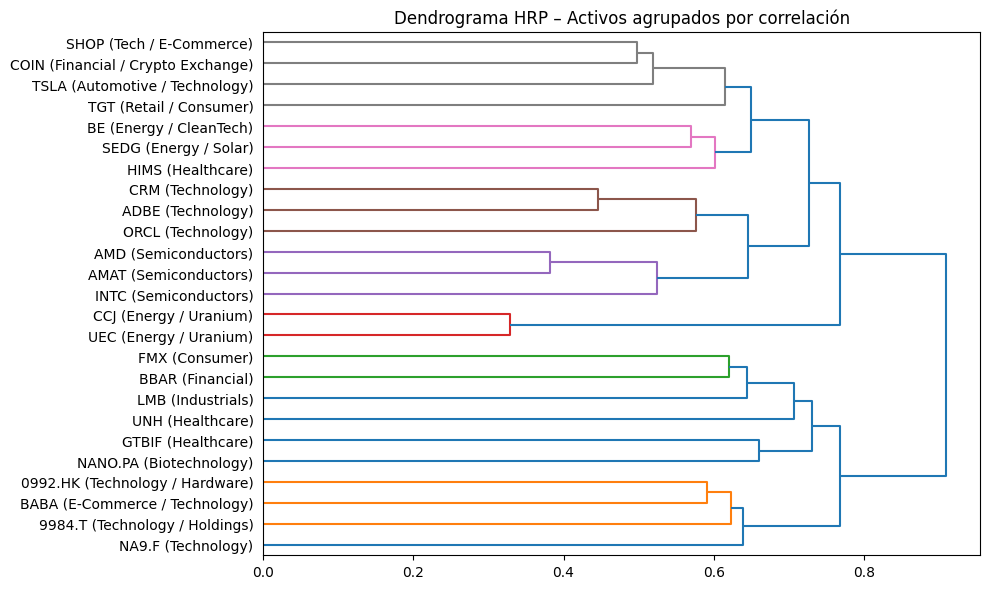

In [93]:
# Dendrograma para visualizar la estructura jerárquica de correlaciones

labels = []
for ticker in selected_assets_ml:
    sec = df_universe.loc[ticker, "sector"] if ticker in df_universe.index else "Unknown"
    labels.append(f"{ticker} ({sec})")

# Matriz de correlación y distancias
corr_sel = returns_sel_T[selected_assets_ml].corr()
dist_sel = np.sqrt((1 - corr_sel) / 2)

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

linkage_sel = linkage(squareform(dist_sel), method="ward")

plt.figure(figsize=(10, 6))
dendrogram(linkage_sel, labels=labels, orientation="right")
plt.title("Dendrograma HRP – Activos agrupados por correlación")
plt.tight_layout()
plt.show()



In [136]:
# Cartera Markowitz optimizada con SLSQP (máximo Sharpe)
# Usamos sólo los activos seleccionados por ML y datos históricos hasta T

import scipy.optimize as sco
from scipy.optimize import minimize

# Subconjunto de activos seleccionados por ML
a_cartera = selected_assets_ml

# Rentabilidades históricas hasta T
returns_m = returns_sel_T[a_cartera]

# Media y covarianza anualizadas (estándar MPT)
mu_m = returns_m.mean() * 252
cov_m = returns_m.cov() * 252

# Pseudoinversa para robustez
cov_inv = np.linalg.pinv(cov_m.values)

# Pesos "raw" proporcionales a Σ⁻¹ μ
w_raw = cov_inv @ mu_m.values

# Convertir a Serie
pesos_markowitz = pd.Series(w_raw, index=a_cartera)

# LIMPIEZA: eliminar posiciones cortas

pesos_markowitz = pesos_markowitz.clip(lower=0)

# Si todo quedó en cero (raro), usar versión raw sin clipping
if pesos_markowitz.sum() == 0:
    pesos_markowitz = pd.Series(w_raw, index=a_cartera)

# Renormalizar
pesos_markowitz = pesos_markowitz / pesos_markowitz.sum()

# Filtrar activos con peso > 0
pesos_markowitz = pesos_markowitz[pesos_markowitz > 0]

# Orden descendente
pesos_markowitz = pesos_markowitz.sort_values(ascending=False)

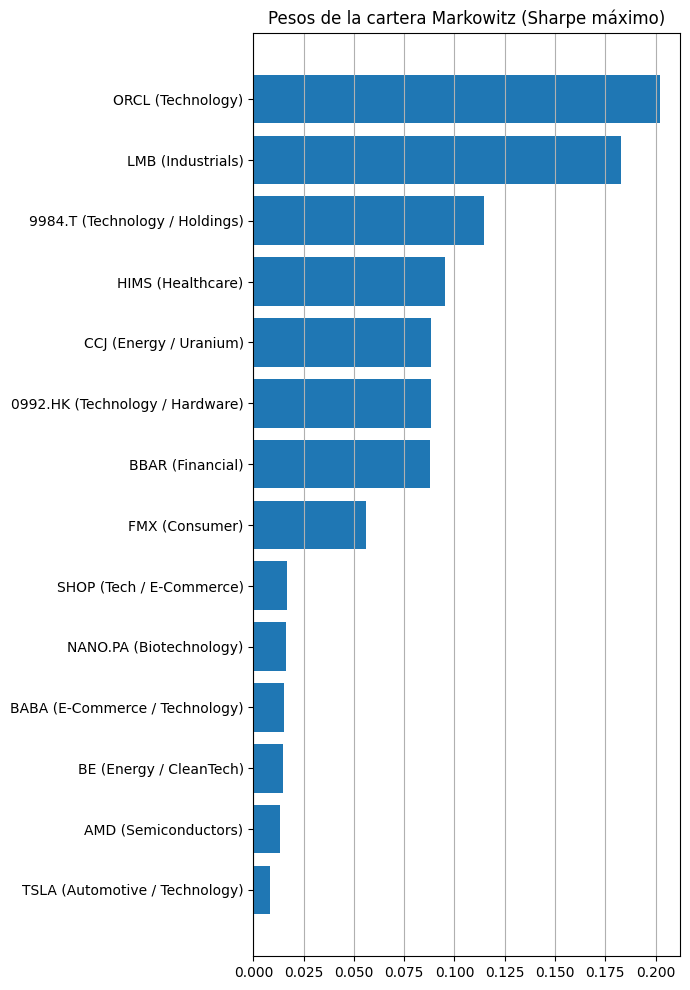

In [137]:
labels_mk = []
for ticker in pesos_markowitz.index:
    sec = df_universe.loc[ticker, "sector"] if ticker in df_universe.index else "Unknown"
    labels_mk.append(f"{ticker} ({sec})")

plt.figure(figsize=(7, 10))
plt.barh(labels_mk, pesos_markowitz.values)
plt.title("Pesos de la cartera Markowitz (Sharpe máximo)")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [141]:
df_weights_markowitz = pd.DataFrame(pesos_markowitz, columns=["weight"])
df_weights_markowitz = df_weights_markowitz.join(
    df_universe[["sector", "country"]],
    how="left"
)
df_weights_markowitz


,weight,sector,country
ORCL,0.202017,Technology,USA
LMB,0.182942,Industrials,USA
9984.T,0.114778,Technology / Holdings,Japan
HIMS,0.095382,Healthcare,USA
CCJ,0.088524,Energy / Uranium,Canada
0992.HK,0.088168,Technology / Hardware,China
BBAR,0.087774,Financial,Argentina
FMX,0.055862,Consumer,Mexico
SHOP,0.016602,Tech / E-Commerce,Canada
NANO.PA,0.016425,Biotechnology,France


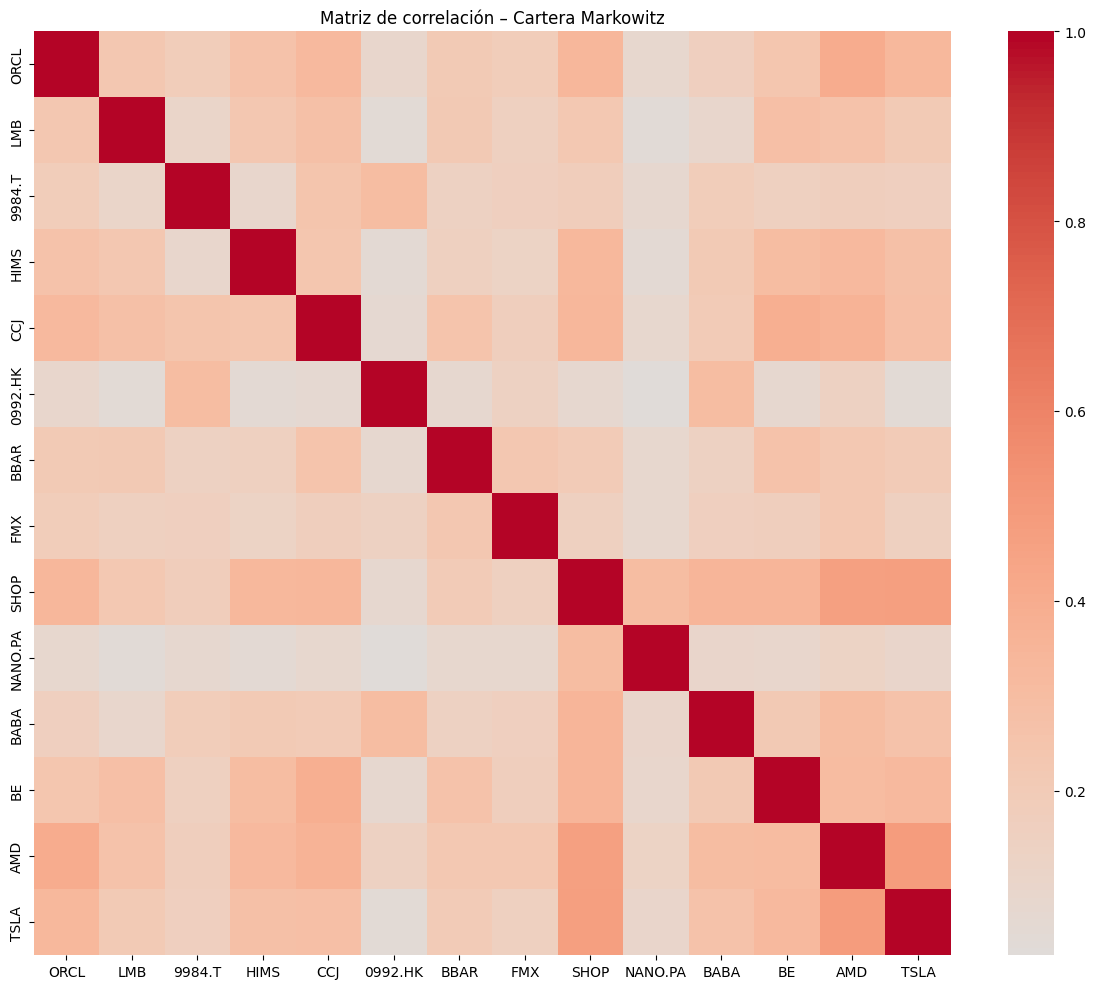

In [142]:
# Heatmap de la matriz de correlación de los activos de Markowitz

activos_mk = df_weights_markowitz.index.tolist()

corr_mk = returns_sel_T[activos_mk].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_mk, cmap="coolwarm", annot=False, center=0)
plt.title("Matriz de correlación – Cartera Markowitz")
plt.tight_layout()
plt.show()


In [145]:
# Comparación de rendimientos reales entre T y hoy (horizon = 21)

# 1. Rentabilidades reales futuras desde T hasta hoy
returns_future = retornos_activos.loc[T:].iloc[:horizon]

# 2. Rendimiento HRP
#    HRP usa todos los activos seleccionados por ML pero ponderados por HRP
weights_hrp_norm = weights_hrp / weights_hrp.sum()
returns_hrp = (returns_future[weights_hrp_norm.index] @ weights_hrp_norm).sum()

# 3. Rendimiento Markowitz (Sharpe máximo)
#    Solo usa los activos con peso real en Markowitz
returns_mk = (returns_future[pesos_markowitz.index] @ pesos_markowitz).sum()

# 4. Rendimiento Equal Weight
#    Usa el universo ML (30 activos o menos)
weights_eq = pd.Series(1/len(selected_assets_ml), index=selected_assets_ml)
returns_eqw = (returns_future[selected_assets_ml] @ weights_eq).sum()

# 5. Tabla comparativa
df_compare = pd.DataFrame({
    "Retorno T → hoy": {
        "HRP": returns_hrp,
        "Markowitz": returns_mk,
        "Equal Weight": returns_eqw
    }
})

df_compare


,Retorno T → hoy
HRP,0.136653
Markowitz,0.110585
Equal Weight,0.196337


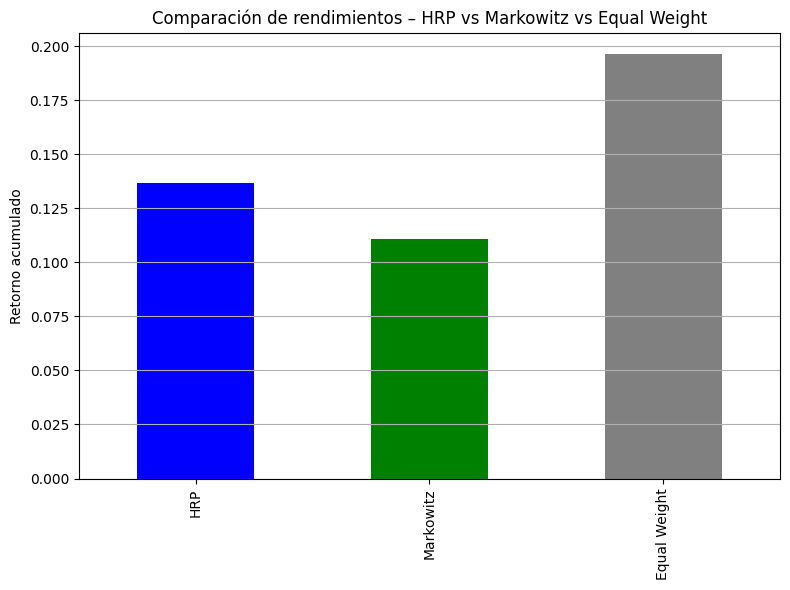

In [144]:
plt.figure(figsize=(8,6))
df_compare["Retorno T → hoy"].plot(kind="bar", color=["blue","green","gray"])
plt.title("Comparación de rendimientos – HRP vs Markowitz vs Equal Weight")
plt.ylabel("Retorno acumulado")
plt.grid(axis="y")
plt.tight_layout()
plt.show()



Los estudios muestran que EW es un benchmark duro de batir cuando la selección previa (stock picking) es fuerte.
HRP sacrifica retorno potencial a cambio de mayor estabilidad y menor concentración.
Markowitz generó una cartera más concentrada y, por tanto, más dependiente de un subconjunto reducido